# EDA

In [ ]:
!pip install numpy pandas seaborn matplotlib joblib

In [1]:
import math

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid", context="notebook")

## 1. Загрузка данных

In [5]:
TRAIN_PATH = "../data/train.parquet"
TEST_PATH = "../data/test.parquet"
UNLABELLED_PATH = "../data/unlabelled.parquet"

train_df = pd.read_parquet(TRAIN_PATH)
test_df = pd.read_parquet(TEST_PATH)
unlabelled_df = pd.read_parquet(UNLABELLED_PATH)

print("./data/train:", train_df.shape)
print("./data/test:", test_df.shape)
print("./data/unlabelled:", unlabelled_df.shape)

./data/train: (1000, 17)
./data/test: (100000, 16)
./data/unlabelled: (200000, 16)


## 2. Быстрый обзор

In [6]:
overview = pd.DataFrame({
    "dataset": ["train", "test", "unlabelled"],
    "rows": [len(train_df), len(test_df), len(unlabelled_df)],
    "cols": [train_df.shape[1], test_df.shape[1], unlabelled_df.shape[1]],
    "target_exists": ["target" in train_df.columns, "target" in test_df.columns, "target" in unlabelled_df.columns],
})
overview

,dataset,rows,cols,target_exists
0,train,1000,17,True
1,test,100000,16,False
2,unlabelled,200000,16,False


In [7]:
common_cols = sorted(set(train_df.columns) & set(test_df.columns) & set(unlabelled_df.columns))
len(common_cols), common_cols[:20]

(16,
 ['hover_timestamp',
  'hover_x',
  'hover_y',
  'mouse_events',
  'mouse_events_total',
  'pointerdown_timestamp',
  'pointerdown_x',
  'pointerdown_y',
  'pointerup_timestamp',
  'pointerup_x',
  'pointerup_y',
  'relative_captcha_init_time',
  'touch_events',
  'touch_events_total',
  'viewport_height',
  'viewport_width'])

In [8]:
dtype_table = pd.DataFrame({
    "column": train_df.columns,
    "train_dtype": train_df.dtypes.astype(str).values,
    "test_dtype": [str(test_df[c].dtype) if c in test_df.columns else None for c in train_df.columns],
    "unlabelled_dtype": [str(unlabelled_df[c].dtype) if c in unlabelled_df.columns else None for c in train_df.columns],
})
dtype_table.head(20)

,column,train_dtype,test_dtype,unlabelled_dtype
0,target,int64,None,None
1,relative_captcha_init_time,float64,float64,float64
2,mouse_events_total,int64,int64,int64
3,mouse_events,object,object,object
4,touch_events_total,int64,int64,int64
5,touch_events,object,object,object
6,pointerdown_timestamp,float64,float64,float64
7,pointerdown_x,int64,int64,int64
8,pointerdown_y,int64,int64,int64
9,pointerup_timestamp,float64,float64,float64


## 3. Базовые статистики по исходным признакам

In [10]:
def missing_report(df, dataset_name):
    out = pd.DataFrame({
        "column": df.columns,
        "missing": df.isna().sum().values,
        "missing_ratio": df.isna().mean().values,
        "dataset": dataset_name,
    })
    return out.sort_values(["missing_ratio", "missing"], ascending=False).reset_index(drop=True)

missing_raw = pd.concat([
    missing_report(train_df, "train"),
    missing_report(test_df, "test"),
    missing_report(unlabelled_df, "unlabelled"),
], ignore_index=True)

missing_raw.head(50)

,column,missing,missing_ratio,dataset
0,target,0,0.0,train
1,relative_captcha_init_time,0,0.0,train
2,mouse_events_total,0,0.0,train
3,mouse_events,0,0.0,train
4,touch_events_total,0,0.0,train
5,touch_events,0,0.0,train
6,pointerdown_timestamp,0,0.0,train
7,pointerdown_x,0,0.0,train
8,pointerdown_y,0,0.0,train
9,pointerup_timestamp,0,0.0,train


In [20]:
raw_numeric_cols = [
    c for c in common_cols
    if pd.api.types.is_numeric_dtype(train_df[c])
    and c != "target"
]

raw_stats_train = train_df[raw_numeric_cols].describe().T.add_prefix("train_")
raw_stats_test = test_df[raw_numeric_cols].describe().T.add_prefix("test_")
raw_stats_unlabelled = unlabelled_df[raw_numeric_cols].describe().T.add_prefix("unlabelled_")


raw_stats_compare = pd.concat([raw_stats_train, raw_stats_test, raw_stats_unlabelled], axis=1)


prefixes = ["train_", "test_", "unlabelled_"]

base_cols = raw_stats_train.columns.str.replace("train_", "", regex=False)

ordered_cols = []
for base_col in base_cols:
    for prefix in prefixes:
        col = prefix + base_col
        if col in raw_stats_compare.columns:
            ordered_cols.append(col)

raw_stats_compare = raw_stats_compare[ordered_cols]
raw_stats_compare

,train_count,test_count,unlabelled_count,train_mean,test_mean,unlabelled_mean,train_std,test_std,unlabelled_std,train_min,test_min,unlabelled_min,train_25%,test_25%,unlabelled_25%,train_50%,test_50%,unlabelled_50%,train_75%,test_75%,unlabelled_75%,train_max,test_max,unlabelled_max
hover_timestamp,1000.0,100000.0,200000.0,21336.287406,18964.758634,2.854641e+04,170182.234897,1.265479e+06,4.104670e+06,0.0,0.0,0.0,2889.150,4266.175,3312.6,4853.00,5475.00,4861.1,11663.775,8586.625,9313.025,3492530.5,269919360.0,1.765905e+09
hover_x,1000.0,100000.0,200000.0,387.201000,149.859170,3.759000e+02,286.183734,1.572860e+02,2.275643e+02,0.0,0.0,0.0,145.750,73.000,134.0,392.00,83.00,392.0,489.000,98.000,484.000,1602.0,2059.0,5.021000e+03
hover_y,1000.0,100000.0,200000.0,443.866000,347.999930,4.427516e+02,229.939122,1.245013e+02,1.575071e+02,0.0,0.0,0.0,405.000,290.000,320.0,581.00,294.00,433.0,600.000,318.000,600.000,840.0,734.0,2.729000e+03
mouse_events_total,1000.0,100000.0,200000.0,133.594000,177.998540,1.632293e+02,106.864986,6.914683e+01,9.340811e+01,0.0,0.0,0.0,70.000,130.000,117.0,120.00,178.00,159.0,181.250,223.000,210.000,999.0,1092.0,4.036000e+03
pointerdown_timestamp,1000.0,100000.0,200000.0,23246.340577,19576.852361,1.766229e+07,170099.640991,1.265477e+06,5.575926e+09,1400.2,0.0,0.0,3981.325,4898.700,3879.2,5942.20,6039.55,5542.2,13316.400,8846.275,9829.850,3492882.5,269919460.0,1.763428e+12
pointerdown_x,1000.0,100000.0,200000.0,398.135000,144.573570,3.756582e+02,262.603533,1.538929e+02,2.234630e+02,33.0,0.0,0.0,165.000,71.000,98.0,392.00,81.00,392.0,485.000,93.000,488.000,1593.0,2059.0,5.002000e+03
pointerdown_y,1000.0,100000.0,200000.0,541.771000,366.301670,4.721876e+02,99.083703,1.152512e+02,1.273014e+02,177.0,0.0,0.0,475.250,300.000,405.0,589.00,313.00,459.0,600.000,338.000,605.000,826.0,746.0,2.713000e+03
pointerup_timestamp,1000.0,100000.0,200000.0,26962.658469,22903.182737,1.766578e+07,170111.983430,1.265483e+06,5.575926e+09,2309.9,0.0,0.0,6758.075,7426.950,6411.0,9880.55,9210.05,8665.8,17853.150,12997.975,13913.750,3496450.5,269919800.0,1.763428e+12
pointerup_x,1000.0,100000.0,200000.0,493.960000,235.417930,4.729829e+02,273.358661,1.626251e+02,2.308359e+02,52.0,48.0,1.0,271.750,135.000,247.0,501.00,181.00,513.0,603.250,237.000,589.000,1728.0,2337.0,5.413000e+03
pointerup_y,1000.0,100000.0,200000.0,540.415000,365.131680,4.719403e+02,114.246974,1.189398e+02,1.248071e+02,-218.0,-444.0,-316.0,467.000,300.000,410.0,590.00,313.00,459.0,605.000,338.000,607.000,865.0,815.0,2.748000e+03


## 4. Простые engineered features

In [21]:
EPS = 1e-9

def _safe_div(a, b):
    try:
        b = float(b)
        if not np.isfinite(b) or abs(b) < EPS:
            return np.nan
        return float(a) / b
    except Exception:
        return np.nan


def _to_df(events):
    if events is None:
        return pd.DataFrame()

    if isinstance(events, np.ndarray):
        events = events.tolist()

    if not isinstance(events, (list, tuple)) or len(events) == 0:
        return pd.DataFrame()

    rows = []
    for e in events:
        if isinstance(e, dict):
            rows.append(e.copy())
        else:
            try:
                rows.append(dict(e))
            except Exception:
                pass

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df.columns = [c[:-1] if isinstance(c, str) and c.endswith("_") else c for c in df.columns]

    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    if "timestamp" in df.columns:
        df = df.sort_values("timestamp").reset_index(drop=True)

    return df


def _mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) else np.nan


def _std(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.std(x)) if len(x) else np.nan


def extract_features(row):
    if isinstance(row, pd.Series):
        row = row.to_dict()
    else:
        row = dict(row)

    feats = {}

    vw = max(float(row.get("viewport_width", np.nan) or 1.0), 1.0)
    vh = max(float(row.get("viewport_height", np.nan) or 1.0), 1.0)

    mouse_df = _to_df(row.get("mouse_events", []))
    touch_df = _to_df(row.get("touch_events", []))

    mouse_total = row.get("mouse_events_total", len(mouse_df))
    touch_total = row.get("touch_events_total", len(touch_df))

    down_ts = float(row.get("pointerdown_timestamp", np.nan))
    up_ts = float(row.get("pointerup_timestamp", np.nan))
    hover_ts = float(row.get("hover_timestamp", np.nan))

    down_x = float(row.get("pointerdown_x", np.nan))
    down_y = float(row.get("pointerdown_y", np.nan))
    up_x = float(row.get("pointerup_x", np.nan))
    up_y = float(row.get("pointerup_y", np.nan))

    feats["has_mouse"] = int(len(mouse_df) > 0 or (pd.notna(mouse_total) and float(mouse_total) > 0))
    feats["has_touch"] = int(len(touch_df) > 0 or (pd.notna(touch_total) and float(touch_total) > 0))
    feats["mouse_events_total"] = float(mouse_total) if pd.notna(mouse_total) else np.nan
    feats["touch_events_total"] = float(touch_total) if pd.notna(touch_total) else np.nan

    feats["viewport_width"] = vw
    feats["viewport_height"] = vh
    feats["viewport_aspect"] = _safe_div(vw, vh)
    feats["relative_captcha_init_time"] = float(row.get("relative_captcha_init_time", np.nan))

    feats["hover_to_down_ms"] = (
        down_ts - hover_ts
        if np.isfinite(down_ts) and np.isfinite(hover_ts) and hover_ts > 0
        else np.nan
    )
    feats["down_to_up_ms"] = (
        up_ts - down_ts
        if np.isfinite(down_ts) and np.isfinite(up_ts)
        else np.nan
    )
    feats["init_to_down_ms"] = (
        down_ts - feats["relative_captcha_init_time"]
        if np.isfinite(down_ts)
        else np.nan
    )
    feats["init_to_up_ms"] = (
        up_ts - feats["relative_captcha_init_time"]
        if np.isfinite(up_ts)
        else np.nan
    )

    feats["pointerdown_x_norm"] = _safe_div(down_x, vw)
    feats["pointerdown_y_norm"] = _safe_div(down_y, vh)
    feats["pointerup_x_norm"] = _safe_div(up_x, vw)
    feats["pointerup_y_norm"] = _safe_div(up_y, vh)

    if len(touch_df) > 0 and "force" in touch_df.columns:
        feats["touch_force_mean"] = _mean(touch_df["force"].values)
        feats["touch_force_std"] = _std(touch_df["force"].values)
    else:
        feats["touch_force_mean"] = np.nan
        feats["touch_force_std"] = np.nan

    return feats


def build_features(df, n_jobs=-1, backend="loky"):
    rows = df.to_dict("records")
    feats = Parallel(n_jobs=n_jobs, backend=backend, batch_size=256, verbose=10)(
        delayed(extract_features)(r) for r in rows
    )
    return pd.DataFrame(feats)

## 5. Создание engineered features для всех датасетов

In [22]:
train_feat = build_features(train_df, n_jobs=-1)
test_feat = build_features(test_df, n_jobs=-1)
unlabelled_feat = build_features(unlabelled_df, n_jobs=-1)

print("train_feat:", train_feat.shape)
print("test_feat:", test_feat.shape)
print("unlabelled_feat:", unlabelled_feat.shape)

train_feat.head()

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  94 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 144 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 206 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 350 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 428 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 518 tasks      | elapsed:    3.8s
[Parallel(n_jobs=-1)]: Done 608 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 710 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 812 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    4.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBac

train_feat: (1000, 18)
test_feat: (100000, 18)
unlabelled_feat: (200000, 18)


,has_mouse,has_touch,mouse_events_total,touch_events_total,viewport_width,viewport_height,viewport_aspect,relative_captcha_init_time,hover_to_down_ms,down_to_up_ms,init_to_down_ms,init_to_up_ms,pointerdown_x_norm,pointerdown_y_norm,pointerup_x_norm,pointerup_y_norm,touch_force_mean,touch_force_std
0,1,0,519.0,0.0,1.0,1.0,1.000000,3157.0,106.0,3465.0,4785.0,8250.0,806.000000,593.000000,872.000000,593.000000,NaN,NaN
1,1,0,118.0,0.0,1920.0,962.0,1.995842,1725.0,959.0,2808.0,8302.0,11110.0,0.437500,0.654886,0.477604,0.662162,NaN,NaN
2,0,1,0.0,45.0,375.0,631.0,0.594295,3463.0,NaN,5368.0,5108.0,10476.0,0.168000,0.803487,0.272000,0.803487,0.08869,0.20544
3,1,0,278.0,0.0,3792.0,2070.0,1.831884,1116.6,300.4,7690.6,4484.1,12174.7,0.377637,0.285507,0.399525,0.298068,NaN,NaN
4,1,0,38.0,0.0,1912.0,962.0,1.987526,1520.9,361.6,2430.1,1936.1,4366.2,0.435146,0.649688,0.457636,0.651767,NaN,NaN


In [23]:
feature_stats_train = train_feat.describe(include="all").T.add_prefix("train_")
feature_stats_test = test_feat.describe(include="all").T.add_prefix("test_")
feature_stats_unlabelled = unlabelled_feat.describe(include="all").T.add_prefix("unlabelled_")

feature_stats_compare = pd.concat([feature_stats_train, feature_stats_test, feature_stats_unlabelled], axis=1)
feature_stats_compare.head(30)

,train_count,train_mean,train_std,train_min,train_25%,train_50%,train_75%,train_max,test_count,test_mean,test_std,test_min,test_25%,test_50%,test_75%,test_max,unlabelled_count,unlabelled_mean,unlabelled_std,unlabelled_min,unlabelled_25%,unlabelled_50%,unlabelled_75%,unlabelled_max
has_mouse,1000.0,0.823000,0.381860,0.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,100000.0,0.985460,1.197027e-01,0.000000,1.000000,1.000000,1.000000,1.000000e+00,200000.0,9.592100e-01,1.978039e-01,0.000000,1.000000,1.000000,1.000000,1.000000e+00
has_touch,1000.0,0.191000,0.393286,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,100000.0,0.014750,1.205512e-01,0.000000,0.000000,0.000000,0.000000,1.000000e+00,200000.0,4.482000e-02,2.069091e-01,0.000000,0.000000,0.000000,0.000000,1.000000e+00
mouse_events_total,1000.0,133.594000,106.864986,0.000000,70.000000,120.000000,1.812500e+02,9.990000e+02,100000.0,177.998540,6.914683e+01,0.000000,130.000000,178.000000,223.000000,1.092000e+03,200000.0,1.632293e+02,9.340811e+01,0.000000,117.000000,159.000000,210.000000,4.036000e+03
touch_events_total,1000.0,23.648000,57.436897,0.000000,0.000000,0.000000,0.000000e+00,3.910000e+02,100000.0,1.662540,1.578653e+01,0.000000,0.000000,0.000000,0.000000,5.330000e+02,200000.0,4.824080e+00,2.754699e+01,0.000000,0.000000,0.000000,0.000000,5.580000e+02
viewport_width,1000.0,1260.977000,734.065750,1.000000,440.750000,1263.000000,1.905000e+03,3.840000e+03,100000.0,1105.308880,3.901840e+02,1.000000,1027.000000,1027.000000,1027.000000,5.079000e+03,200000.0,1.308695e+03,4.699677e+02,1.000000,1027.000000,1027.000000,1905.000000,1.024000e+04
viewport_height,1000.0,745.768000,298.578427,1.000000,610.000000,731.000000,9.370000e+02,2.070000e+03,100000.0,649.993800,1.917959e+02,1.000000,610.000000,610.000000,662.000000,2.419000e+03,200000.0,7.331086e+02,1.799497e+02,1.000000,610.000000,662.000000,922.000000,5.117000e+03
viewport_aspect,1000.0,1.590031,0.575548,0.483871,1.000000,1.773667,2.015873e+00,3.252874e+00,100000.0,1.663403,2.210351e-01,0.439024,1.683607,1.683607,1.683607,5.515152e+00,200000.0,1.751645e+00,3.335626e-01,0.250597,1.683607,1.683607,1.995842,5.515152e+00
relative_captcha_init_time,1000.0,2841.165706,3035.158751,134.400000,1338.750000,1689.000000,3.423450e+03,3.520440e+04,100000.0,3050.042107,3.024620e+03,126.600000,1513.800000,2092.300000,3406.525000,1.915218e+05,200000.0,3.192464e+03,9.895674e+03,0.000000,1440.000000,1829.100000,3611.600000,4.115384e+06
hover_to_down_ms,819.0,551.333420,3233.080906,-11655.000000,79.000000,272.000000,5.202000e+02,6.378460e+04,98506.0,481.795186,1.057831e+03,-31138.300000,418.900000,602.800000,787.900000,3.745980e+04,191260.0,2.864246e+02,1.975446e+03,-49409.200000,62.600000,376.000000,609.300000,8.564070e+04
down_to_up_ms,1000.0,3716.317892,2817.097194,21.300000,1999.075000,3053.650000,4.857275e+03,3.142300e+04,100000.0,3326.330377,2.227464e+03,0.000000,1857.300000,2822.400000,4117.525000,1.167072e+05,200000.0,3.497302e+03,3.054469e+03,-26636.300000,1927.300000,2824.800000,4049.625000,8.057550e+04


## 6. Графики

In [ ]:
def make_compare_df(train_series, test_series, feature_name):
    return pd.DataFrame({
        "value": pd.concat([train_series, test_series], axis=0, ignore_index=True),
        "dataset": ["train"] * len(train_series) + ["test"] * len(test_series),
        "feature": feature_name,
    })


def plot_hist_compare(train_df_local, test_df_local, cols, bins=40, ncols=2, figsize_scale=4, unlabeled_df_local=None):
    cols = [c for c in cols if c in train_df_local.columns and c in test_df_local.columns]
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 7, nrows * figsize_scale))
    axes = np.array(axes).reshape(-1)

    for ax, col in zip(axes, cols):
        plot_df = make_compare_df(train_df_local[col], test_df_local[col], col)
        # if unlabeled_df_local is not None:
        # plot_df = make_compare_df
        plot_df = plot_df[np.isfinite(plot_df["value"])]

        xmax = plot_df["value"].quantile(0.99)
        plot_df_cut = plot_df[plot_df["value"] <= xmax].copy()


        sns.histplot(
            data=plot_df_cut,
            x="value",
            hue="dataset",
            bins=bins,
            stat="density",
            common_norm=False,
            element="step",
            fill=True,
            ax=ax,
        )
        ax.set_title(col)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def plot_box_compare(
    train_df,
    test_df,
    cols,
    ncols=2,
    figsize_scale=4,
    q_low=0.01,
    q_high=0.99,
    log1p_cols=None,
    kind="violin",
    unlabeled_df_local=None,
):
    if isinstance(cols, str):
        cols = [cols]

    if log1p_cols is None:
        log1p_cols = set()
    else:
        log1p_cols = set(log1p_cols)

    n = len(cols)
    nrows = math.ceil(n / ncols)

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_scale * ncols, figsize_scale * nrows),
        squeeze=False,
    )
    axes = axes.ravel()

    palette = {"train": "#4C72B0", "test": "#DD8452", 'unlabeled': "#C2E812"}

    for ax, col in zip(axes, cols):
        if unlabeled_df_local is None:
            plot_df = pd.concat([
                pd.DataFrame({"value": train_df[col], "dataset": "train"}),
                pd.DataFrame({"value": test_df[col], "dataset": "test"}),
            ], ignore_index=True)
        elif unlabeled_df_local is not None:
            plot_df = pd.concat([
                pd.DataFrame({"value": train_df[col], "dataset": "train"}),
                pd.DataFrame({"value": test_df[col], "dataset": "test"}),
                pd.DataFrame({"value": unlabeled_df_local[col], "dataset": "unlabeled"}),
            ])

        plot_df = plot_df[np.isfinite(plot_df["value"])].copy()

        use_log = col in log1p_cols
        if use_log:
            plot_df["value"] = np.log1p(plot_df["value"])
            xlabel = f"log1p({col})"
        else:
            xlabel = col

        if len(plot_df) > 0:
            lo = plot_df["value"].quantile(q_low)
            hi = plot_df["value"].quantile(q_high)
            plot_df = plot_df[plot_df["value"].between(lo, hi)].copy()

        if kind == "violin":
            sns.violinplot(
                data=plot_df,
                x="value",
                y="dataset",
                orient="h",
                cut=0,
                inner="quartile",
                linewidth=1,
                palette=palette,
                ax=ax,
            )
        else:
            sns.boxenplot(
                data=plot_df,
                x="value",
                y="dataset",
                orient="h",
                linewidth=1,
                palette=palette,
                k_depth="trustworthy",
                ax=ax,
            )

        med = (
            plot_df.groupby("dataset", as_index=False)["value"]
            .median()
            .rename(columns={"value": "median"})
        )
        sns.scatterplot(
            data=med,
            x="median",
            y="dataset",
            color="black",
            s=30,
            ax=ax,
            zorder=5,
            legend=False,
        )

        ax.set_title(col, fontsize=15, pad=10)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("")
        ax.grid(axis="x", alpha=0.2)
        sns.despine(ax=ax, left=True, bottom=False)

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [26]:
raw_plot_cols = [
    "relative_captcha_init_time",
    "mouse_events_total",
    "touch_events_total",
    "pointerdown_timestamp",
    "pointerup_timestamp",
    "viewport_width",
    "viewport_height",
]
raw_plot_cols = [c for c in raw_plot_cols if c in train_df.columns and c in test_df.columns]
raw_plot_cols

['relative_captcha_init_time',
 'mouse_events_total',
 'touch_events_total',
 'pointerdown_timestamp',
 'pointerup_timestamp',
 'viewport_width',
 'viewport_height']

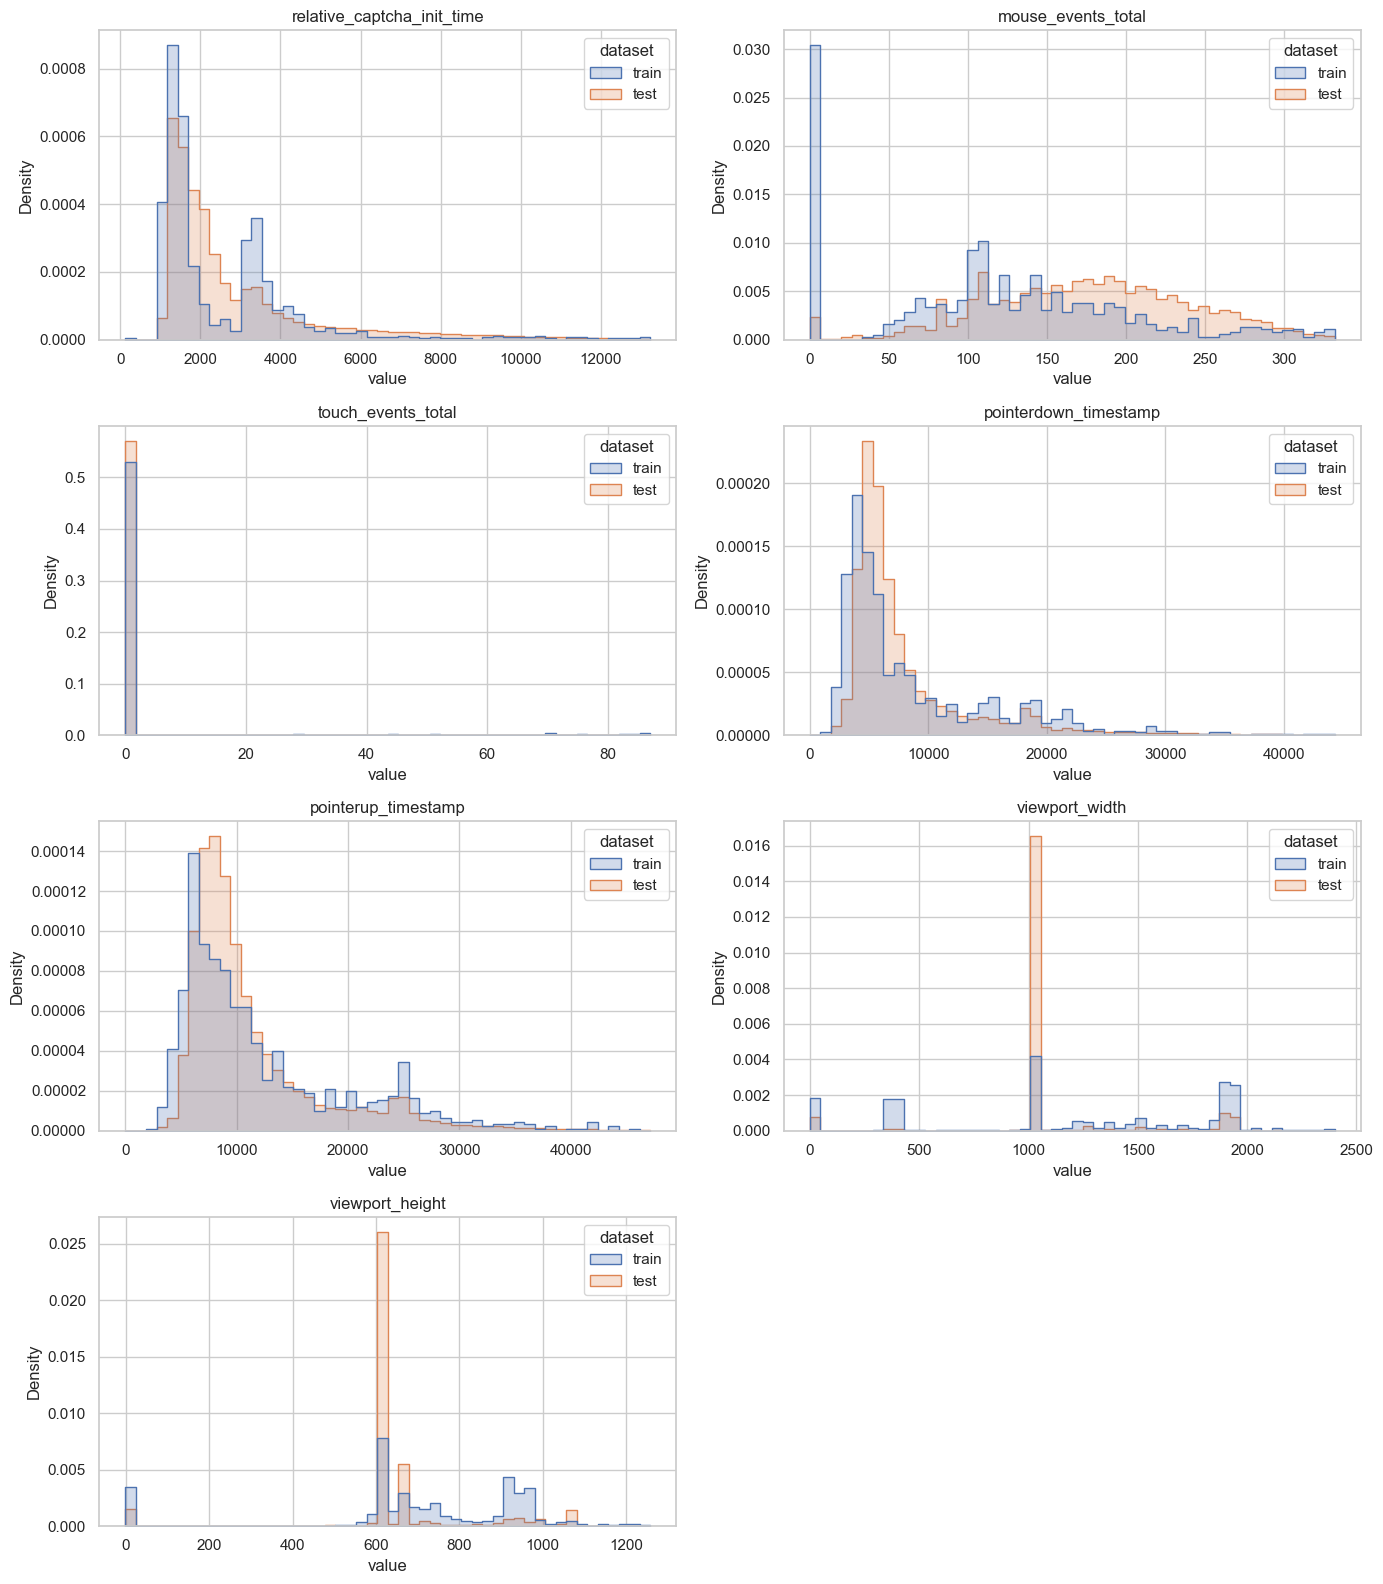

In [34]:
plot_hist_compare(train_df, test_df, raw_plot_cols, bins=50, ncols=2, figsize_scale=4, unlabeled_df_local=unlabelled_df)

NameError: name 'unlabelled_df_local' is not defined

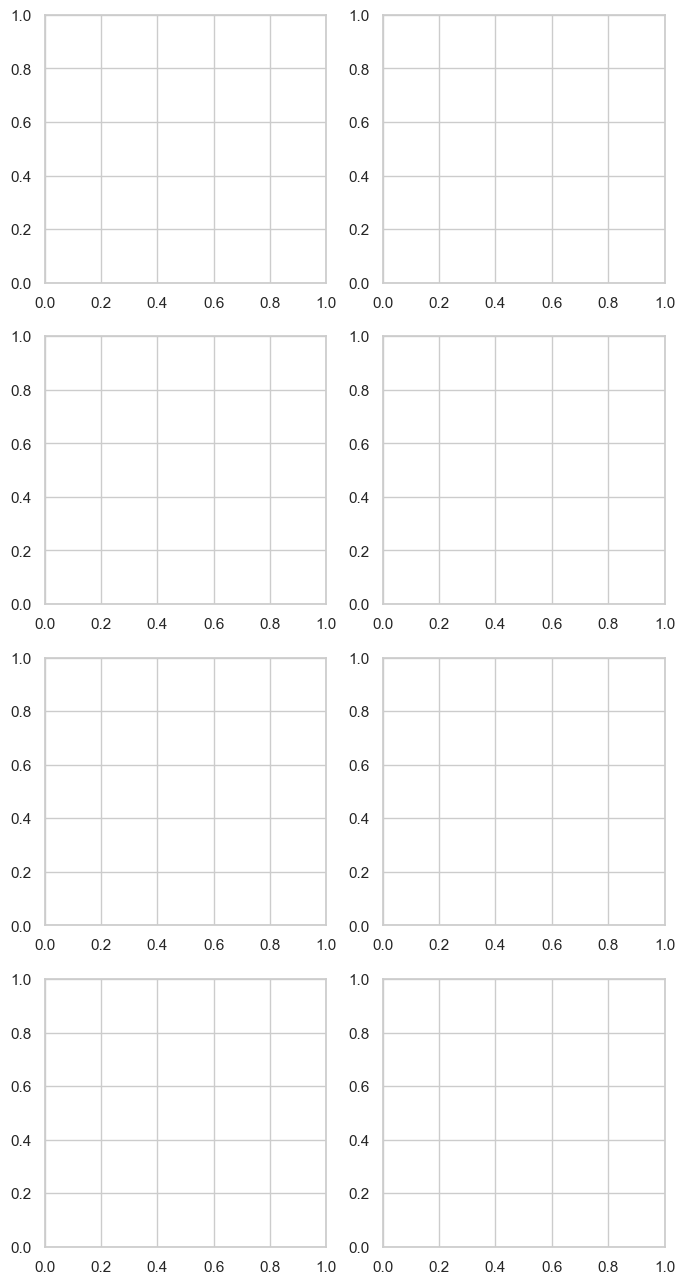

In [43]:
plot_box_compare(train_df, unlabelled_df, raw_plot_cols, ncols=2, figsize_scale=4, unlabeled_df_local=unlabelled_df)

## 7. Графики по engineered features: train vs test

In [ ]:
engineered_plot_cols = [
    "has_mouse",
    "has_touch",
    "mouse_events_total",
    "touch_events_total",
    "viewport_width",
    "viewport_height",
    "viewport_aspect",
    "relative_captcha_init_time",
    "hover_to_down_ms",
    "down_to_up_ms",
    "init_to_down_ms",
    "init_to_up_ms",
    "pointerdown_x_norm",
    "pointerdown_y_norm",
    "pointerup_x_norm",
    "pointerup_y_norm",
    "touch_force_mean",
    "touch_force_std",
]
engineered_plot_cols = [c for c in engineered_plot_cols if c in train_feat.columns and c in test_feat.columns]
engineered_plot_cols

['has_mouse',
 'has_touch',
 'mouse_events_total',
 'touch_events_total',
 'viewport_width',
 'viewport_height',
 'viewport_aspect',
 'relative_captcha_init_time',
 'hover_to_down_ms',
 'down_to_up_ms',
 'init_to_down_ms',
 'init_to_up_ms',
 'pointerdown_x_norm',
 'pointerdown_y_norm',
 'pointerup_x_norm',
 'pointerup_y_norm',
 'touch_force_mean',
 'touch_force_std']

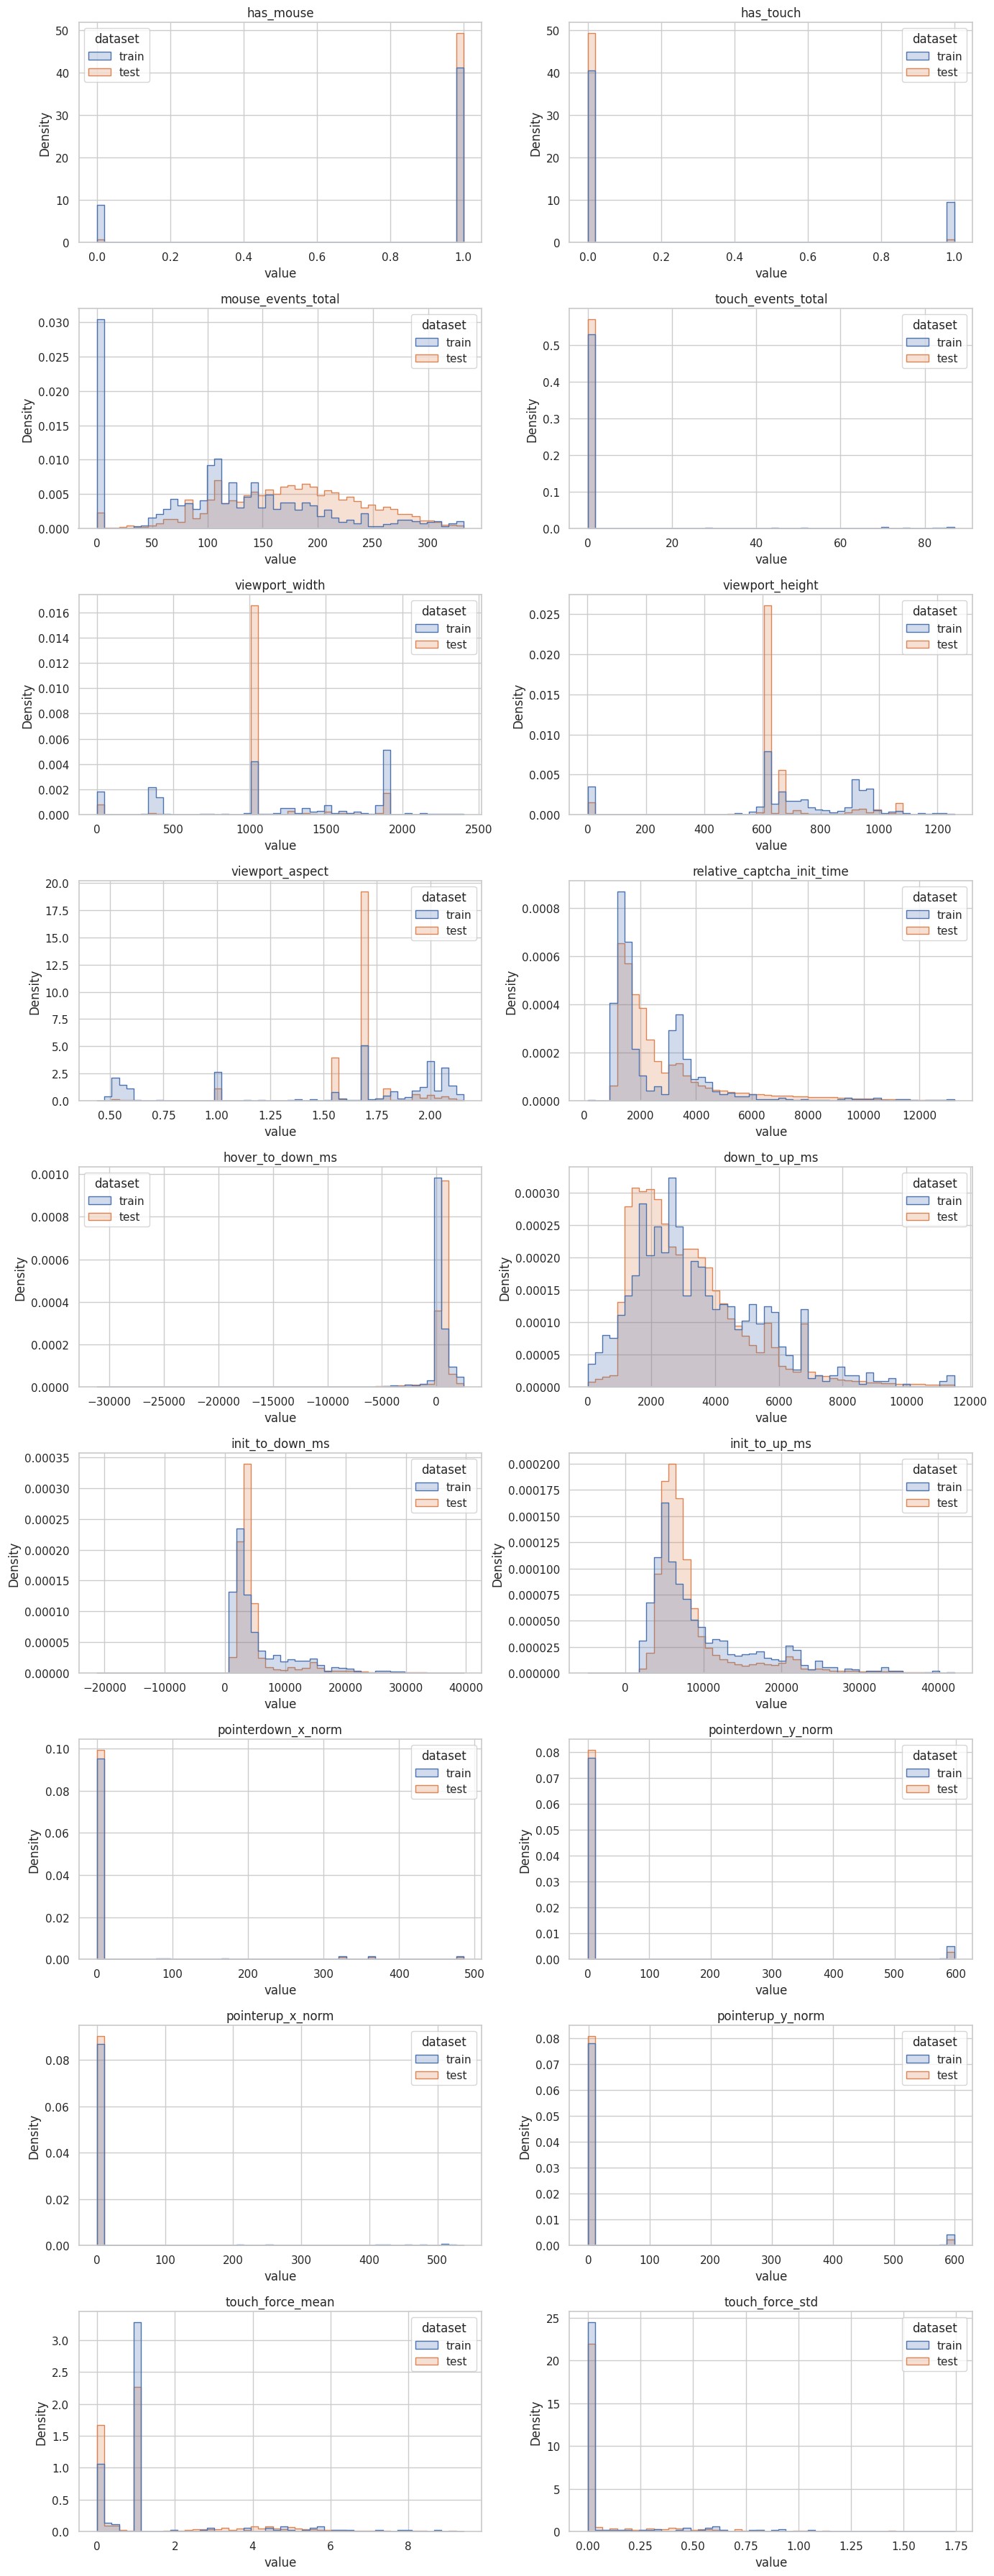

In [ ]:
plot_hist_compare(train_feat, test_feat, engineered_plot_cols, bins=50, ncols=2, figsize_scale=4)

In [36]:
plot_box_compare(train_feat, test_feat, engineered_plot_cols, ncols=2, figsize_scale=4, unlabeled_df_local=unlabelled_df)

NameError: name 'engineered_plot_cols' is not defined

## 8. Разница между train и test по engineered features

In [ ]:
compare_summary = pd.DataFrame({
    "feature": engineered_plot_cols,
    "train_mean": [train_feat[c].mean() for c in engineered_plot_cols],
    "test_mean": [test_feat[c].mean() for c in engineered_plot_cols],
    "train_std": [train_feat[c].std() for c in engineered_plot_cols],
    "test_std": [test_feat[c].std() for c in engineered_plot_cols],
})
compare_summary["mean_diff"] = compare_summary["train_mean"] - compare_summary["test_mean"]
compare_summary["abs_mean_diff"] = compare_summary["mean_diff"].abs()
compare_summary.sort_values("abs_mean_diff", ascending=False)

,feature,train_mean,test_mean,train_std,test_std,mean_diff,abs_mean_diff
11,init_to_up_ms,24121.492763,19853.140630,170137.477167,1.265478e+06,4268.352133,4268.352133
10,init_to_down_ms,20405.174871,16526.810253,170137.612499,1.265473e+06,3878.364618,3878.364618
9,down_to_up_ms,3716.317892,3326.330377,2817.097194,2.227464e+03,389.987515,389.987515
7,relative_captcha_init_time,2841.165706,3050.042107,3035.158751,3.024620e+03,-208.876401,208.876401
4,viewport_width,1260.977000,1105.308880,734.065750,3.901840e+02,155.668120,155.668120
5,viewport_height,745.768000,649.993800,298.578427,1.917959e+02,95.774200,95.774200
8,hover_to_down_ms,551.333420,481.795186,3233.080906,1.057831e+03,69.538234,69.538234
2,mouse_events_total,133.594000,177.998540,106.864986,6.914683e+01,-44.404540,44.404540
15,pointerup_y_norm,49.414267,22.750044,161.891437,1.127205e+02,26.664223,26.664223
13,pointerdown_y_norm,49.212024,22.720972,161.217865,1.125860e+02,26.491052,26.491052


## 9. Target-статистики в train по сырым признакам

In [ ]:
raw_target_stats = train_df.groupby("target")[raw_plot_cols].agg(["mean", "median", "std"])
raw_target_stats

relative_captcha_init_time                       mouse_events_total  \
                             mean   median          std               mean   
target                                                                       
0                     3423.723742  2581.35  3506.274176            163.074   
1                     2258.607670  1539.50  2338.540581            104.114   

                          touch_events_total                    \
       median         std               mean median        std   
target                                                           
0       143.0   95.217253              6.918    0.0  30.871108   
1        95.0  109.796117             40.378    0.0  71.348949   

       pointerdown_timestamp                         pointerup_timestamp  \
                        mean   median            std                mean   
target                                                                     
0               19631.264114  8277.70  157204.472025        23844.366106   
1               26861.417040  5254.75  182171.137981        30080.950832   

                                viewport_width                      \
          median            std           mean  median         std   
target                                                               
0       12018.40  157283.957647       1242.688  1027.0  636.401981   
1        8773.35  182143.998448       1279.096  1453.5  820.696499   

       viewport_height                     
                  mean median         std  
target                                     
0              693.246  662.0  294.343142  
1              798.120  794.0  294.249069

In [ ]:
train_feat_with_target = train_feat.copy()
train_feat_with_target["target"] = train_df["target"].values
feat_target_stats = train_feat_with_target.groupby("target")[engineered_plot_cols].agg(["mean", "median", "std"])
feat_target_stats

has_mouse                  has_touch                   \
            mean median       std      mean median       std   
target                                                         
0          0.946    1.0  0.226244     0.056    0.0  0.230152   
1          0.700    1.0  0.458717     0.326    0.0  0.469217   

       mouse_events_total                    touch_events_total         \
                     mean median         std               mean median   
target                                                                   
0                 163.074  143.0   95.217253              6.918    0.0   
1                 104.114   95.0  109.796117             40.378    0.0   

                  viewport_width                     viewport_height         \
              std           mean  median         std            mean median   
target                                                                        
0       30.871108       1242.790  1027.0  636.202450         693.348  662.0   
1       71.348949       1279.164  1453.5  820.590335         798.188  794.0   

                   viewport_aspect                      \
               std            mean    median       std   
target                                                   
0       294.102485        1.687020  1.683607  0.412295   
1       294.064300        1.493042  1.920674  0.688721   

       relative_captcha_init_time                       hover_to_down_ms  \
                             mean   median          std             mean   
target                                                                     
0                     3423.723742  2581.35  3506.274176       412.549647   
1                     2258.607670  1539.50  2338.540581       741.058058   

                            down_to_up_ms                        \
        median          std          mean   median          std   
target                                                            
0       293.40  1174.634211   4213.101992  3542.10  2880.305349   
1       265.25  4778.449861   3219.533792  2678.05  2664.064590   

       init_to_down_ms                         init_to_up_ms           \
                  mean   median            std          mean   median   
target                                                                  
0         16207.540372  4160.80  157230.303118  20420.642364  8594.55   
1         24602.809370  3054.25  182194.799313  27822.343162  6643.20   

                      pointerdown_x_norm                        \
                  std               mean    median         std   
target                                                           
0       157291.529443          37.330711  0.262582  115.180146   
1       182163.275930          25.284401  0.249868  121.692469   

       pointerdown_y_norm                       pointerup_x_norm            \
                     mean    median         std             mean    median   
target                                                                       
0               61.023671  0.663934  179.500664        47.156723  0.359740   
1               37.400377  0.680256  139.765549        32.259693  0.385658   

                   pointerup_y_norm                       touch_force_mean  \
               std             mean    median         std             mean   
target                                                                       
0       144.089415        61.041289  0.672131  179.603069         2.033730   
1       142.315229        37.787245  0.686331  141.216210         1.232169   

                        touch_force_std                   
       median       std            mean median       std  
target                                                    
0         1.0  2.225017        0.158546    0.0  0.248786  
1         1.0  1.567489        0.087707    0.0  0.301464

## 11. Корреляции engineered features в train

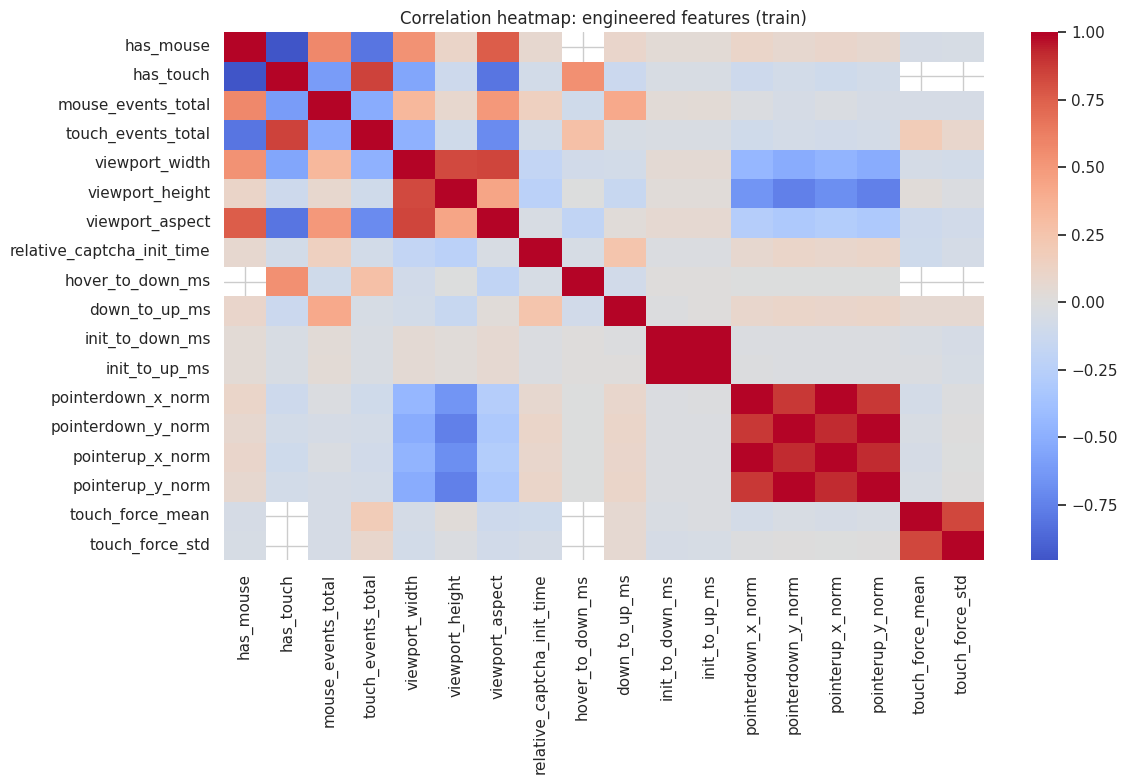

In [ ]:
corr_cols = [c for c in engineered_plot_cols if pd.api.types.is_numeric_dtype(train_feat[c])]
corr = train_feat[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap: engineered features (train)")
plt.tight_layout()
plt.show()

## 12. Сравнение train vs unlabelled по engineered features

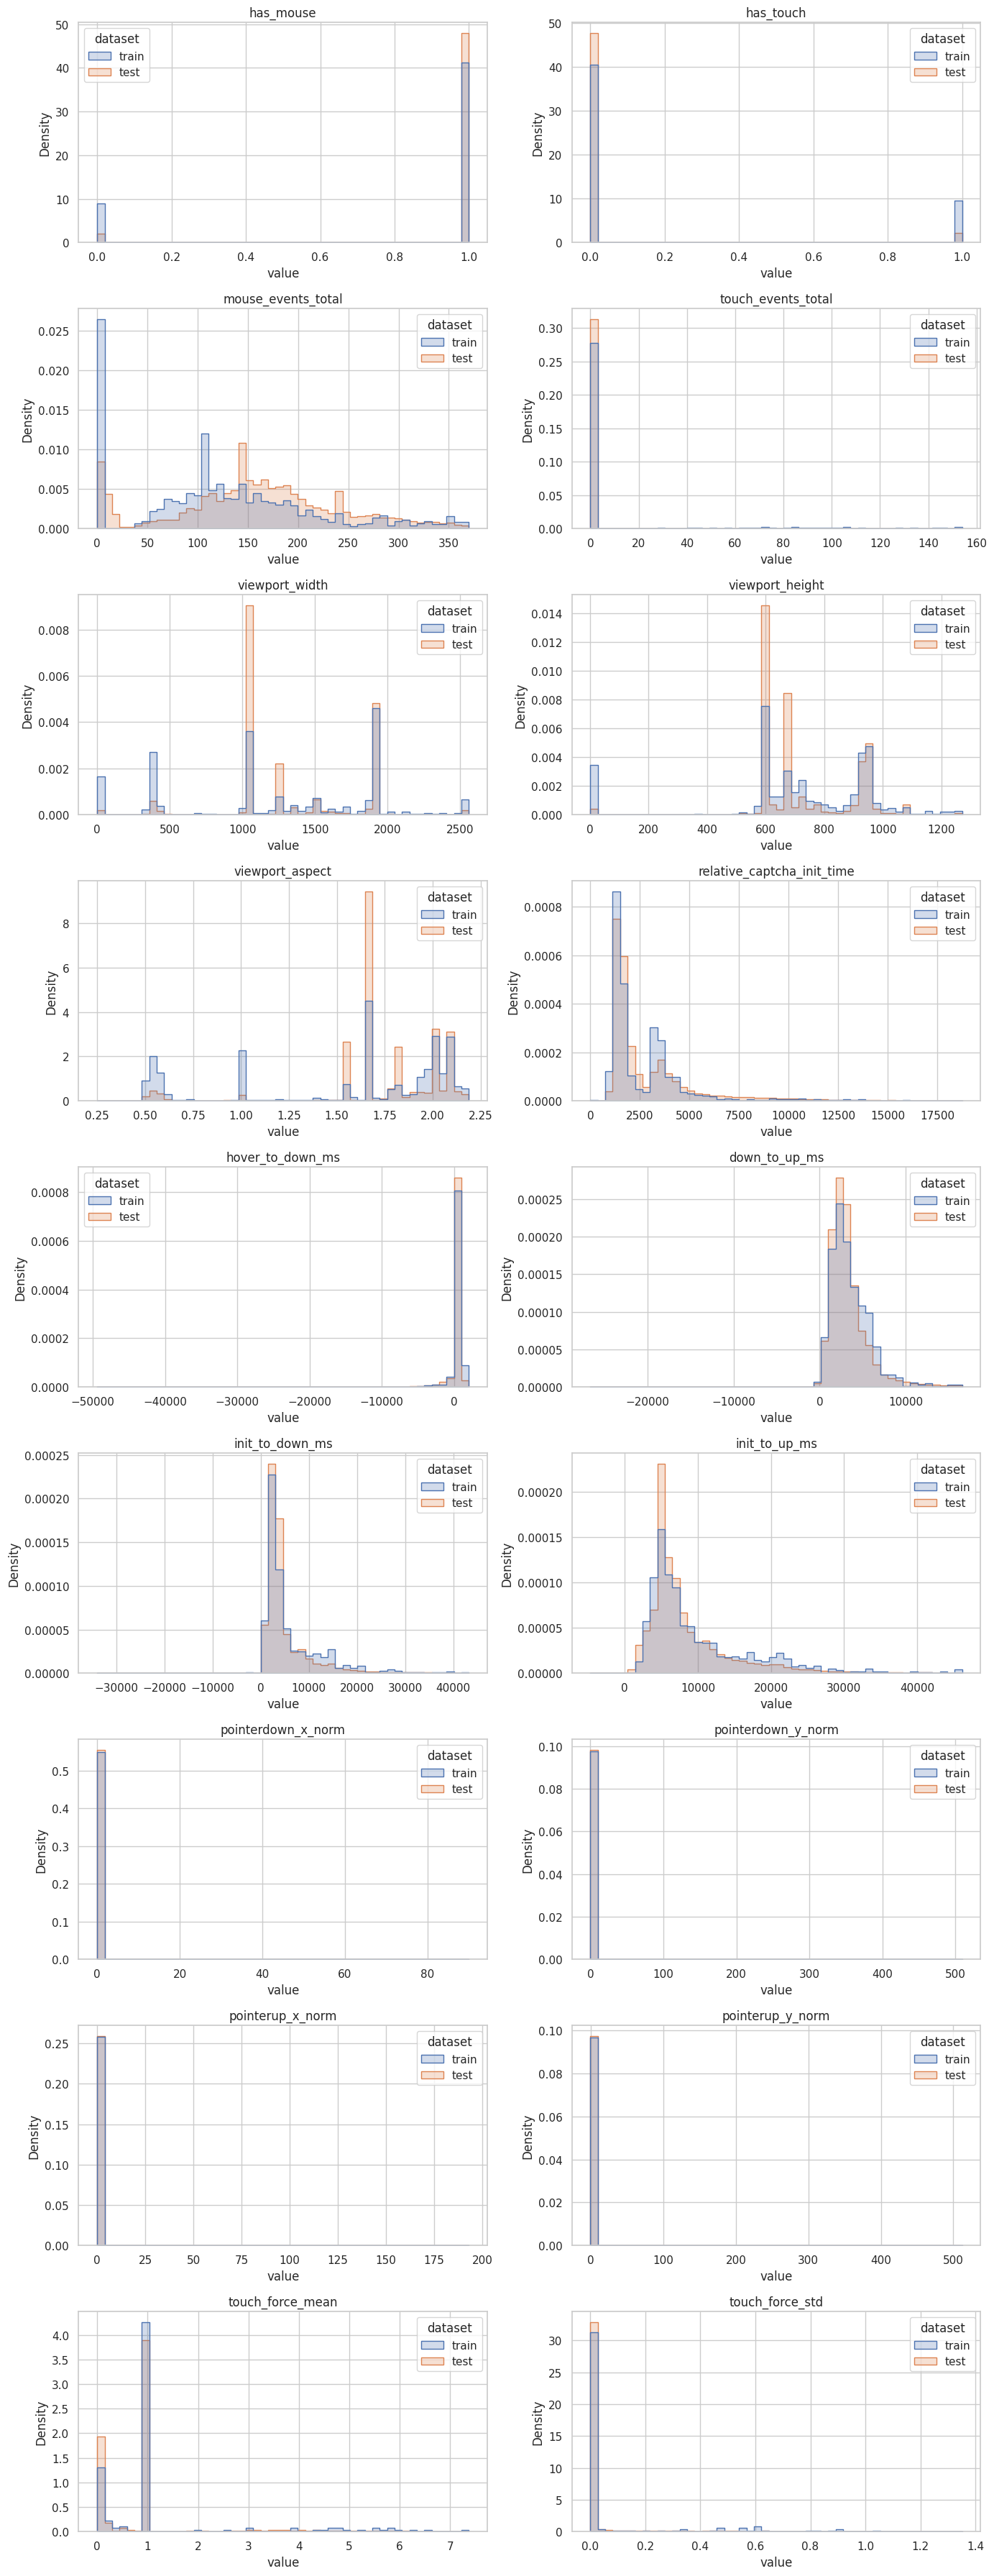

In [ ]:
plot_hist_compare(train_feat, unlabelled_feat, engineered_plot_cols, bins=50, ncols=2, figsize_scale=4)